# Demand Forecasting for Event and Business Bookings in the Hospitality Industry
## Forecasting Analysis Notebook

This notebook contains the forecasting analysis for the bachelor thesis:

"Demand Forecasting for Event and Business Bookings in the Hospitality Industry: A Case Study of De Hofdame."

The analysis focuses on forecasting hospitality booking demand using time-series forecasting techniques, including SARIMA and SARIMAX models. Both original weekly demand and capped routine operational demand are analysed to evaluate the impact of exceptional high-demand periods on forecasting performance.

The notebook includes:
- data preparation and aggregation,
- exploratory time-series analysis,
- baseline forecasting,
- SARIMA modelling,
- SARIMAX modelling with explanatory variables,
- evaluation using MAE and RMSE,
- and export of forecasting outputs for operational interpretation and dashboard prototyping.

## Loading and preparing the data

The booking dataset was imported and prepared for time-series analysis. Date values were converted to datetime format and used as the dataframe index to enable temporal aggregation and forecasting.

In [388]:
import pandas as pd

# Load booking dataset
df = pd.read_csv("Hofdame Historical Booking Data.csv")

# Convert date column to datetime format
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

# Sort observations chronologically
df = df.sort_values("date")

# Set date column as dataframe index for time-series analysis
df = df.set_index("date")

print(df.head())

             weekday  pax       location
date                                    
2024-01-07    zondag   25        hofdame
2024-01-07    zondag   10  heer ivo zaal
2024-01-07    zondag   16        hofdame
2024-01-10  woensdag   10  heer ivo zaal
2024-01-10  woensdag   15     nassauzaal


**Daily demand aggregation**

Daily guest demand was aggregated by summing the total number of guests per day. Missing dates were filled with zero values to preserve a continuous daily time series for forecasting analysis.

In [389]:
# Aggregate total guest counts by day
ts = df["pax"].resample("D").sum()

# Fill missing days with zero demand
ts = ts.fillna(0)

print(ts.head(10))

date
2024-01-07     51
2024-01-08      0
2024-01-09      0
2024-01-10     25
2024-01-11      4
2024-01-12    130
2024-01-13      0
2024-01-14      0
2024-01-15      0
2024-01-16      0
Freq: D, Name: pax, dtype: int64


The daily time series was visualised to inspect overall demand behaviour, volatility, and potential temporal patterns prior to forecasting.

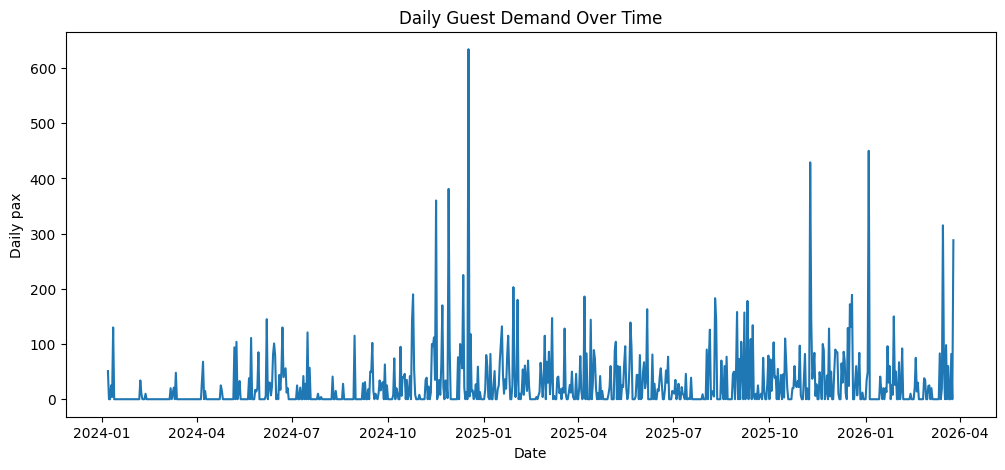

In [390]:
import matplotlib.pyplot as plt

# Visualise daily guest demand
plt.figure(figsize=(12,5))

plt.plot(ts.index, ts.values)

plt.title("Daily Guest Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Daily pax")

plt.show()

## Daily SARIMA model

A SARIMA model was first fitted to the daily demand series to evaluate whether short-term daily booking patterns could be forecasted. Daily demand was expected to be volatile because individual event bookings can strongly affect specific days.

In [391]:
# Split daily demand into training and test sets
# The final 30 days are used as the test period
train = ts[:-30]
test = ts[-30:]

print("Training period:", train.index.min(), "to", train.index.max())
print("Test period:", test.index.min(), "to", test.index.max())

Training period: 2024-01-07 00:00:00 to 2026-02-24 00:00:00
Test period: 2026-02-25 00:00:00 to 2026-03-26 00:00:00


The SARIMA model was fitted using the training data only. Forecast accuracy was then evaluated on the final 30 days of observed demand.

In [392]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit SARIMA model to daily demand
model = SARIMAX(
    train,
    order=(0, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

print(results.summary())

                                     SARIMAX Results                                     
Dep. Variable:                               pax   No. Observations:                  780
Model:             SARIMAX(0, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -4101.164
Date:                           Thu, 04 Jun 2026   AIC                           8210.328
Time:                                   10:50:22   BIC                           8228.877
Sample:                               01-07-2024   HQIC                          8217.470
                                    - 02-24-2026                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -1.0367      0.012    -85.043      0.000      -1.061      -1.013
ar.S.L7        0.0015      0.040      0.037

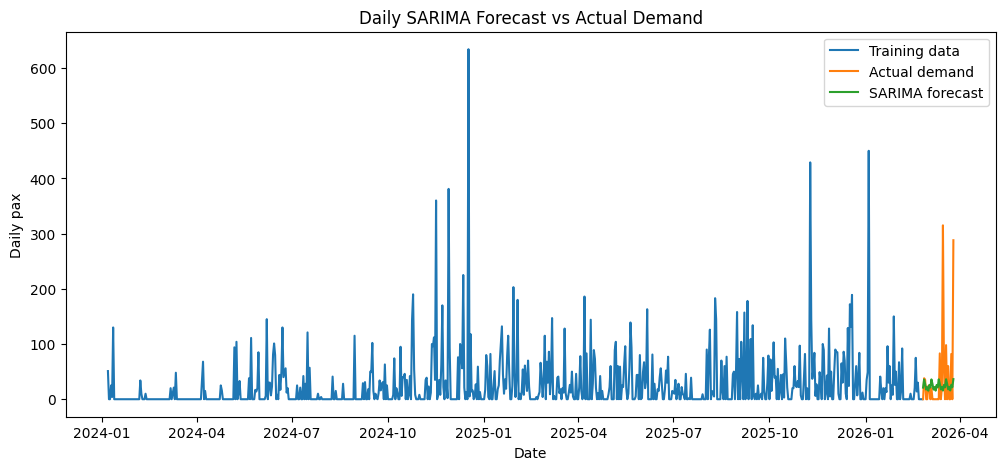

In [393]:
# Forecast daily demand for the test period
forecast = results.forecast(steps=len(test))

plt.figure(figsize=(12,5))

plt.plot(train.index, train, label="Training data")
plt.plot(test.index, test, label="Actual demand")
plt.plot(forecast.index, forecast, label="SARIMA forecast")

plt.title("Daily SARIMA Forecast vs Actual Demand")
plt.xlabel("Date")
plt.ylabel("Daily pax")
plt.legend()

plt.show()

In [394]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Evaluate daily SARIMA forecast accuracy
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("Daily SARIMA MAE:", mae)
print("Daily SARIMA RMSE:", rmse)

Daily SARIMA MAE: 40.14916367184363
Daily SARIMA RMSE: 76.25113687352274


The daily SARIMA model provides an initial benchmark for daily demand forecasting. However, daily demand is highly volatile, which limits the model's ability to capture sudden peaks caused by individual bookings or events.

## Weekly demand aggregation

The daily demand series was aggregated to weekly level to reduce short-term fluctuations and align the forecasting task with broader operational planning needs.

In [395]:
# Aggregate daily demand to weekly demand
weekly_ts = ts.resample("W").sum()

# Inspect weekly demand series
print(weekly_ts.head())
print(weekly_ts.tail())

date
2024-01-07     51
2024-01-14    159
2024-01-21      0
2024-01-28      0
2024-02-04      0
Freq: W-SUN, Name: pax, dtype: int64
date
2026-03-01     73
2026-03-08     69
2026-03-15    103
2026-03-22    526
2026-03-29    370
Freq: W-SUN, Name: pax, dtype: int64


## Baseline forecasting model

A naive baseline forecasting model was created to provide a simple reference point for evaluating the performance of the SARIMA and SARIMAX models. The baseline model predicts future demand using the final observed value from the training period.

In [396]:
# Split weekly demand into training and test sets
train_w = weekly_ts[:-8]
test_w = weekly_ts[-8:]

# Create naive baseline forecast using the final observed training value
baseline_forecast = pd.Series(
    train_w.iloc[-1],
    index=test_w.index
)

# Evaluate baseline forecast accuracy
baseline_mae = mean_absolute_error(test_w, baseline_forecast)
baseline_rmse = np.sqrt(mean_squared_error(test_w, baseline_forecast))

print("Weekly baseline MAE:", baseline_mae)
print("Weekly baseline RMSE:", baseline_rmse)

Weekly baseline MAE: 170.375
Weekly baseline RMSE: 180.97962592513002


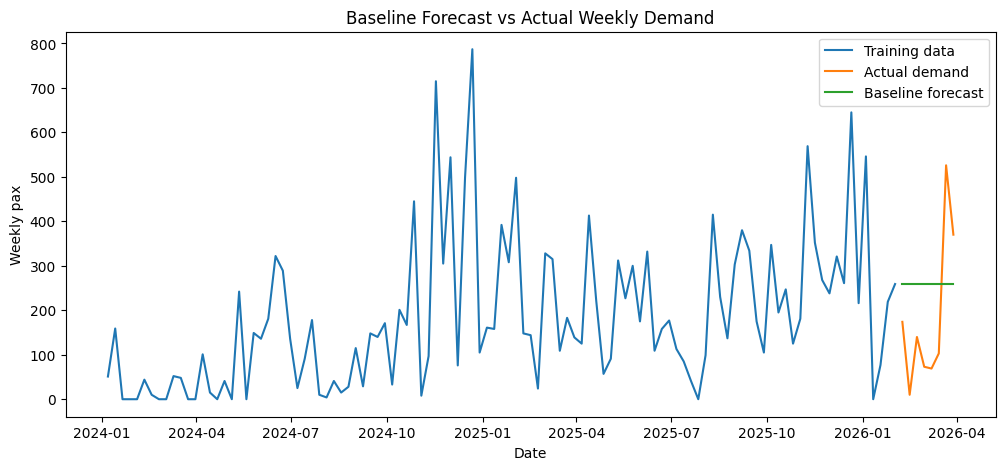

In [397]:
# Visualise baseline forecast against actual weekly demand
plt.figure(figsize=(12,5))

plt.plot(train_w.index, train_w, label="Training data")
plt.plot(test_w.index, test_w, label="Actual demand")
plt.plot(baseline_forecast.index, baseline_forecast,
         label="Baseline forecast")

plt.title("Baseline Forecast vs Actual Weekly Demand")
plt.xlabel("Date")
plt.ylabel("Weekly pax")
plt.legend()

plt.show()

## Weekly SARIMA model

Weekly demand was modelled to reduce the volatility present in the daily time series. Aggregating demand to the weekly level provides a smoother forecasting target and better reflects operational planning decisions such as staffing, preparation, and expected workload.

In [398]:
# Fit SARIMA model to weekly demand
model_w = SARIMAX(
    train_w,
    order=(0, 1, 1),
    seasonal_order=(1, 0, 0, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_w = model_w.fit(disp=False)

print(results_w.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                 pax   No. Observations:                  109
Model:             SARIMAX(0, 1, 1)x(1, 0, [], 52)   Log Likelihood                -357.305
Date:                             Thu, 04 Jun 2026   AIC                            720.610
Time:                                     10:50:24   BIC                            726.686
Sample:                                 01-07-2024   HQIC                           722.965
                                      - 02-01-2026                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -1.0000      0.210     -4.761      0.000      -1.412      -0.588
ar.S.L52       0.1587      

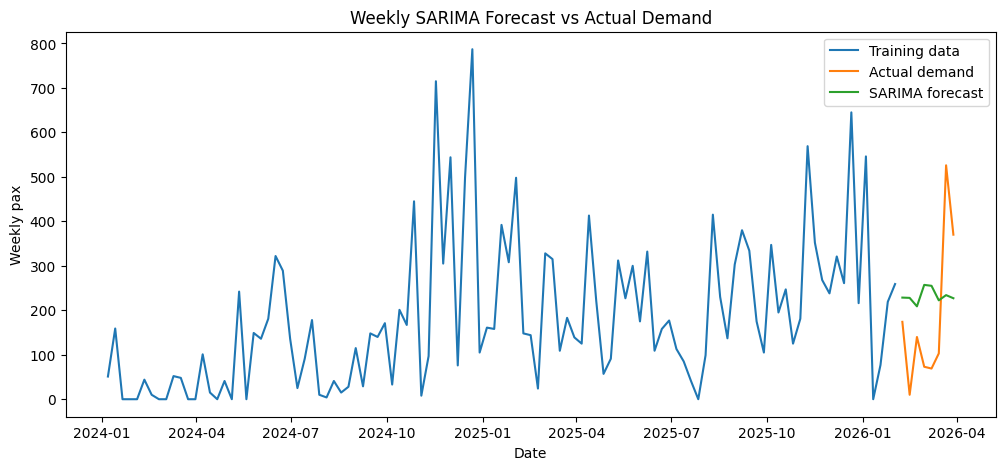

In [399]:
# Forecast weekly demand for the test period
forecast_w = results_w.forecast(steps=len(test_w))

# Prevent impossible negative guest counts
forecast_w = np.maximum(forecast_w, 0)

plt.figure(figsize=(12,5))

plt.plot(train_w.index, train_w, label="Training data")
plt.plot(test_w.index, test_w, label="Actual demand")
plt.plot(forecast_w.index, forecast_w, label="SARIMA forecast")

plt.title("Weekly SARIMA Forecast vs Actual Demand")
plt.xlabel("Date")
plt.ylabel("Weekly pax")
plt.legend()

plt.show()

In [400]:
# Evaluate weekly SARIMA forecast accuracy
mae_w = mean_absolute_error(test_w, forecast_w)
rmse_w = np.sqrt(mean_squared_error(test_w, forecast_w))

print("Weekly SARIMA MAE:", mae_w)
print("Weekly SARIMA RMSE:", rmse_w)

Weekly SARIMA MAE: 158.19011328646565
Weekly SARIMA RMSE: 174.48492029584935


The weekly SARIMA model was used to evaluate whether aggregating demand to the weekly level improved forecast stability compared with the daily model. Weekly aggregation reduces day-to-day noise, but demand may still be affected by irregular event-driven peaks.

## Weekly SARIMAX model

To extend the weekly SARIMA model, explanatory variables were added through a SARIMAX specification. These variables were intended to capture broader seasonal patterns and temporal trends that may influence hospitality demand beyond the autoregressive structure of the time series itself.

The initial SARIMAX model included a linear time trend and weekly seasonality variables. Weekly seasonality was encoded using sine and cosine transformations to represent recurring annual patterns.

In [401]:
# Create dataframe for SARIMAX feature engineering
weekly_df = pd.DataFrame({
    "pax": weekly_ts
})

# Create temporal trend feature
weekly_df["week_number"] = range(len(weekly_df))

# Extract week-of-year component
weekly_df["week_of_year"] = weekly_df.index.isocalendar().week.astype(int)

# Encode cyclical weekly seasonality across the year
weekly_df["week_sin"] = np.sin(2 * np.pi * weekly_df["week_of_year"] / 52)
weekly_df["week_cos"] = np.cos(2 * np.pi * weekly_df["week_of_year"] / 52)


In [402]:
# Create Dutch public holiday indicator
import holidays

years = list(
    range(
        weekly_df.index.min().year,
        weekly_df.index.max().year + 1
    )
)

nl_holidays = holidays.NL(years=years)

weekly_df["is_holiday_week"] = 0

for holiday_date in nl_holidays.keys():
    holiday_date = pd.to_datetime(holiday_date)

    weekly_df.loc[
        (weekly_df.index <= holiday_date) &
        (weekly_df.index + pd.Timedelta(days=6) >= holiday_date),
        "is_holiday_week"
    ] = 1


In [403]:
# School vacation weeks for Regio Noord
school_vacations = [
    ("2024-10-26", "2024-11-03"),
    ("2024-12-21", "2025-01-05"),
    ("2025-02-15", "2025-02-23"),
    ("2025-04-26", "2025-05-04"),
    ("2025-07-12", "2025-08-24"),

    ("2025-10-18", "2025-10-26"),
    ("2025-12-20", "2026-01-04"),
    ("2026-02-21", "2026-03-01"),
    ("2026-04-25", "2026-05-03"),
    ("2026-07-04", "2026-08-16"),
]

# Create school vacation indicator
weekly_df["is_school_vacation_week"] = 0

# Mark weeks containing school vacation days
for start, end in school_vacations:

    start = pd.to_datetime(start)
    end = pd.to_datetime(end)

    weekly_df.loc[
        (weekly_df.index <= end) &
        (weekly_df.index + pd.Timedelta(days=6) >= start),
        "is_school_vacation_week"
    ] = 1

In [404]:
# Define target and explanatory variables
y = weekly_df["pax"]

X = weekly_df[
    [
        "week_number",
        "week_sin",
        "week_cos",
        "is_holiday_week",
        "is_school_vacation_week"
    ]
]

print(X.head())

            week_number  week_sin  week_cos  is_holiday_week  \
date                                                           
2024-01-07            0  0.120537  0.992709                0   
2024-01-14            1  0.239316  0.970942                0   
2024-01-21            2  0.354605  0.935016                0   
2024-01-28            3  0.464723  0.885456                0   
2024-02-04            4  0.568065  0.822984                0   

            is_school_vacation_week  
date                                 
2024-01-07                        0  
2024-01-14                        0  
2024-01-21                        0  
2024-01-28                        0  
2024-02-04                        0  


The same eight-week test period was used to enable direct comparison between the SARIMA and SARIMAX models.

In [405]:
# Split target and explanatory variables into training and test sets
train_y = y[:-8]
test_y = y[-8:]

train_X = X[:-8]
test_X = X[-8:]

In [406]:
# Fit SARIMAX model with explanatory variables
model_x = SARIMAX(
    train_y,
    exog=train_X,
    order=(0, 1, 1),
    seasonal_order=(1, 0, 0, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_x = model_x.fit(disp=False)

print(results_x.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                      
Dep. Variable:                                 pax   No. Observations:                  109
Model:             SARIMAX(0, 1, 1)x(1, 0, [], 52)   Log Likelihood                -351.239
Date:                             Thu, 04 Jun 2026   AIC                            718.478
Time:                                     10:50:31   BIC                            734.681
Sample:                                 01-07-2024   HQIC                           724.760
                                      - 02-01-2026                                         
Covariance Type:                               opg                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
week_number                -0.5556      2.531     -0.220      0.826      -5.515 

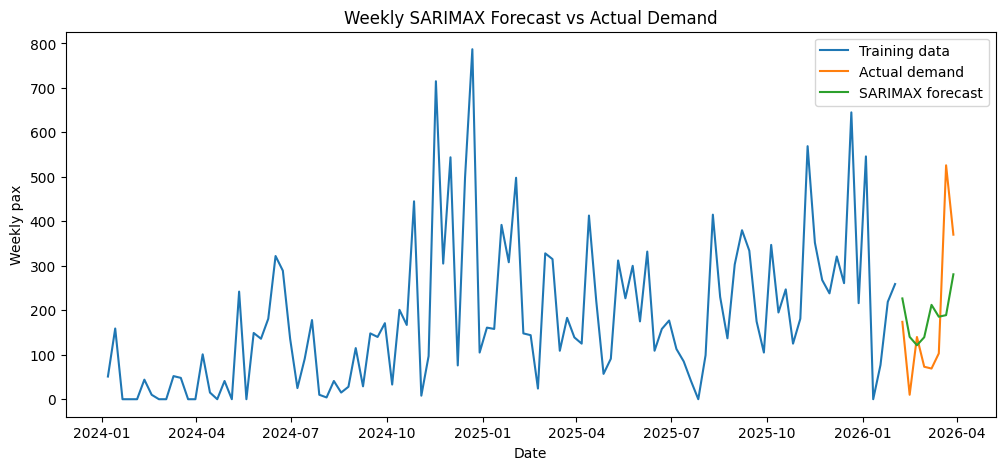

In [407]:
# Forecast weekly demand using SARIMAX
forecast_x = results_x.forecast(
    steps=len(test_y),
    exog=test_X
)

# Prevent impossible negative guest counts
forecast_x = np.maximum(forecast_x, 0)

plt.figure(figsize=(12,5))

plt.plot(train_y.index, train_y, label="Training data")
plt.plot(test_y.index, test_y, label="Actual demand")
plt.plot(forecast_x.index, forecast_x, label="SARIMAX forecast")

plt.title("Weekly SARIMAX Forecast vs Actual Demand")
plt.xlabel("Date")
plt.ylabel("Weekly pax")
plt.legend()

plt.show()

In [408]:
# Evaluate weekly SARIMAX forecast accuracy
mae_x = mean_absolute_error(test_y, forecast_x)
rmse_x = np.sqrt(mean_squared_error(test_y, forecast_x))

print("Weekly SARIMAX MAE:", mae_x)
print("Weekly SARIMAX RMSE:", rmse_x)

Weekly SARIMAX MAE: 114.94262579694714
Weekly SARIMAX RMSE: 147.15793366701834


The initial SARIMAX model evaluated whether adding temporal explanatory variables improved forecasting performance compared with the SARIMA benchmark. The included variables represent broad seasonal and trend-related demand patterns, holidays and school vacations.

# Routine vs exceptional demand

The initial weekly forecasting models showed limited predictive performance, partly due to large fluctuations and several exceptionally high-demand weeks within the dataset. In hospitality forecasting, these extreme peaks may reflect irregular events, celebrations, or other context-specific circumstances that are difficult to predict using historical booking patterns alone.

To investigate whether routine operational demand could be forecasted more effectively, a second analysis was conducted in which exceptional demand peaks were capped at a predefined threshold. This approach preserves the temporal continuity of the time series while reducing the disproportionate influence of rare extreme observations.

The objective of this section is therefore not to remove important business events, but to evaluate whether forecasting regular operational demand produces more stable and practically useful forecasting results.

## Exploring weekly demand distribution

Before defining a threshold for exceptional demand, the distribution of weekly guest demand was explored using descriptive statistics and visualisations. This exploratory analysis was used to identify potential outliers and determine a reasonable threshold for separating routine operational demand from exceptional peak weeks.

In [409]:
# Inspect weekly demand distribution
print(weekly_ts.describe())

count    117.000000
mean     183.803419
std      166.739175
min        0.000000
25%       51.000000
50%      148.000000
75%      268.000000
max      787.000000
Name: pax, dtype: float64


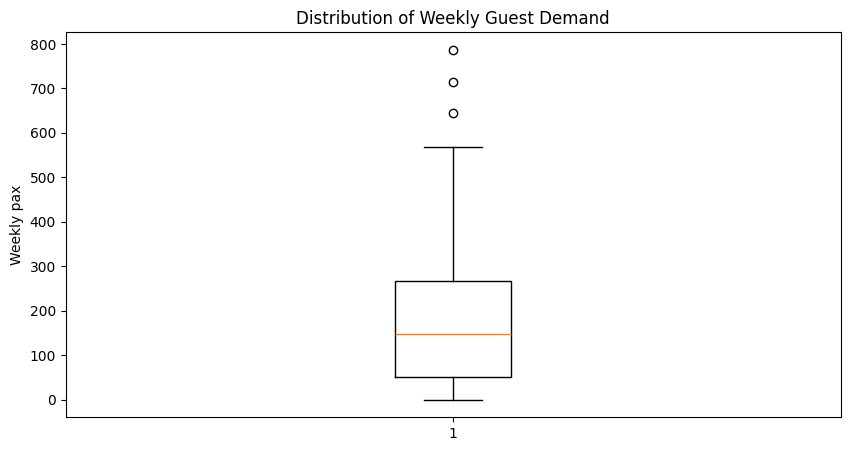

In [410]:
# Boxplot to identify potential outliers in weekly demand
plt.figure(figsize=(10,5))

plt.boxplot(weekly_ts)

plt.title("Distribution of Weekly Guest Demand")
plt.ylabel("Weekly pax")

plt.show()

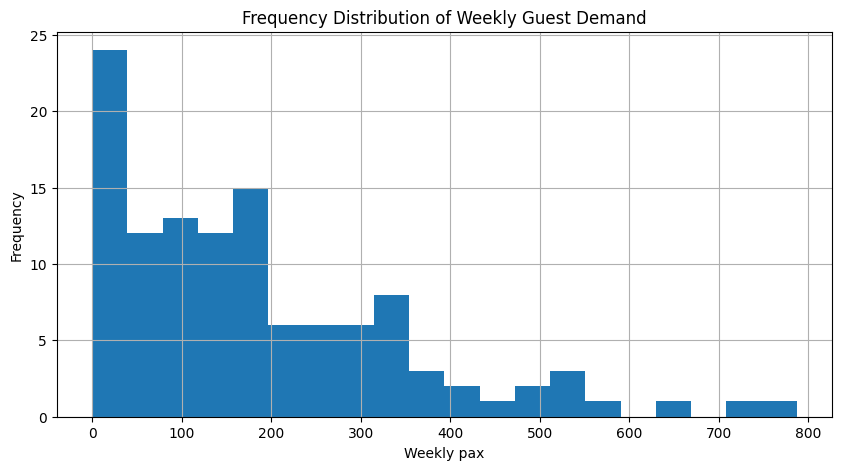

In [411]:
# Histogram to inspect frequency distribution of weekly demand
plt.figure(figsize=(10,5))

weekly_ts.hist(bins=20)

plt.title("Frequency Distribution of Weekly Guest Demand")
plt.xlabel("Weekly pax")
plt.ylabel("Frequency")

plt.show()

To further understand the nature of high-demand periods, one representative high-demand week was inspected at the daily level. This allows assessment of whether exceptional weekly demand resulted from a single extreme event or from consistently elevated daily demand throughout the week.

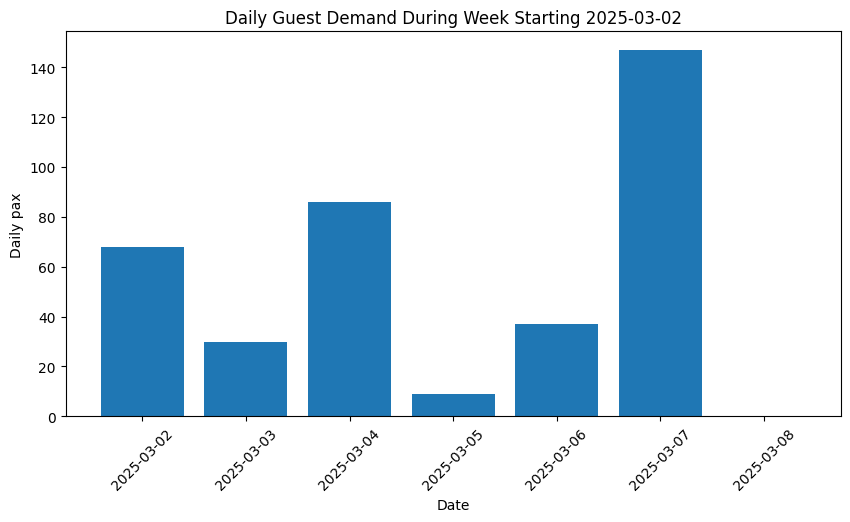

In [412]:
# Select representative high-demand week
selected_week = "2025-03-02"

week_start = pd.to_datetime(selected_week)
week_end = week_start + pd.Timedelta(days=6)

week_data = ts.loc[week_start:week_end]

# Visualise daily distribution within selected week
plt.figure(figsize=(10,5))

plt.bar(week_data.index, week_data.values)

plt.title(f"Daily Guest Demand During Week Starting {selected_week}")
plt.ylabel("Daily pax")
plt.xlabel("Date")

plt.xticks(rotation=45)

plt.show()

## Defining the exceptional demand threshold

Based on exploratory analysis of the weekly demand distribution and discussions with De Hofdame, a threshold of 300 guests per week was selected to distinguish routine operational demand from exceptional peak demand.

Weekly observations above this threshold were capped at 300 pax. This threshold was chosen because observations above this level appeared relatively infrequent and substantially exceeded the typical operational range observed throughout the dataset, which is supported by discussions with De Hofdame.

In [413]:
# Define threshold for exceptional demand
threshold = 300

# Create capped routine-demand series
weekly_routine_ts = weekly_ts.clip(upper=threshold)

# Inspect resulting capped distribution
print(weekly_routine_ts.describe())

count    117.000000
mean     153.692308
std      108.812514
min        0.000000
25%       51.000000
50%      148.000000
75%      268.000000
max      300.000000
Name: pax, dtype: float64


## Comparing original and capped demand series

The original and capped weekly demand series were visualised to evaluate the impact of the thresholding procedure on overall demand patterns.

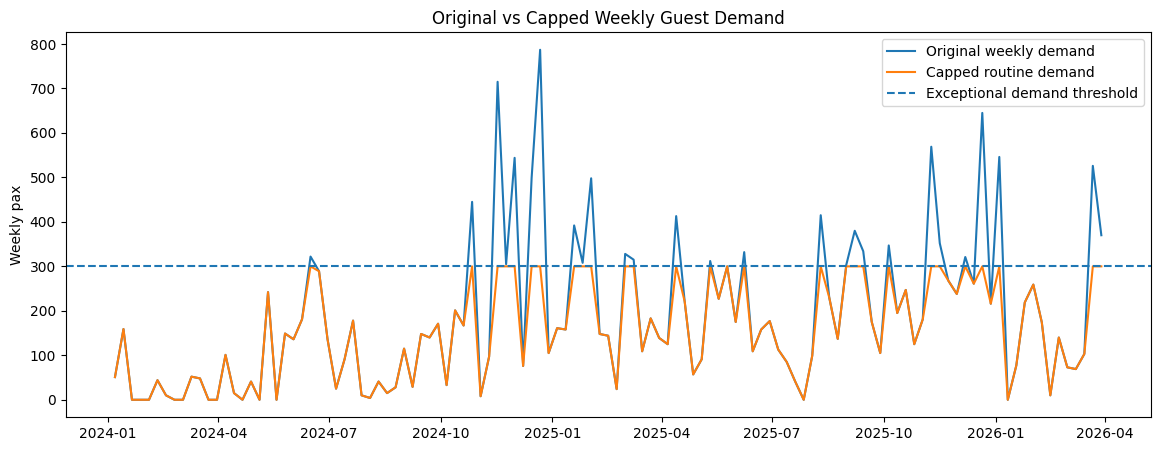

In [414]:
# Compare original and capped weekly demand series
plt.figure(figsize=(14,5))

plt.plot(
    weekly_ts.index,
    weekly_ts,
    label="Original weekly demand"
)

plt.plot(
    weekly_routine_ts.index,
    weekly_routine_ts,
    label="Capped routine demand"
)

plt.axhline(
    threshold,
    linestyle="--",
    label="Exceptional demand threshold"
)

plt.title("Original vs Capped Weekly Guest Demand")
plt.ylabel("Weekly pax")

plt.legend()

plt.show()

## Routine demand baseline model

A naive baseline model was first applied to the capped routine-demand series. The baseline forecast assumes that future demand remains equal to the final observed value in the training set.

This baseline serves as a benchmark against which the routine-demand forecasting models can be evaluated.

In [415]:
# Train-test split for capped routine demand
train_r = weekly_routine_ts[:-8]
test_r = weekly_routine_ts[-8:]

# Naive forecast using last observed training value
baseline_r_forecast = pd.Series(
    train_r.iloc[-1],
    index=test_r.index
)

# Evaluate forecast performance
baseline_r_mae = mean_absolute_error(test_r, baseline_r_forecast)
baseline_r_rmse = np.sqrt(mean_squared_error(test_r, baseline_r_forecast))

print("Routine baseline MAE:", baseline_r_mae)
print("Routine baseline RMSE:", baseline_r_rmse)

Routine baseline MAE: 133.375
Routine baseline RMSE: 150.7402567332297


## Routine demand SARIMA model

A SARIMA model was then fitted to the capped routine-demand series to evaluate whether reducing the influence of exceptional demand peaks improved forecasting performance relative to the original weekly demand models.

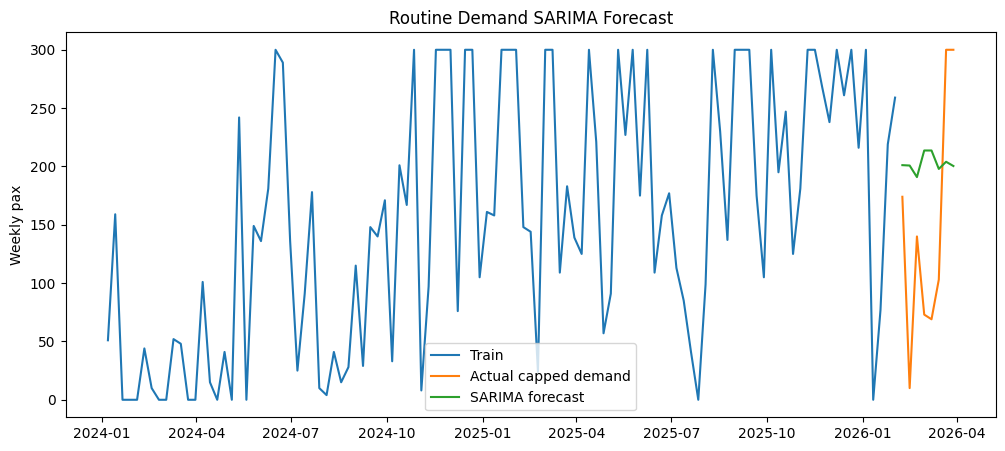

Routine SARIMA MAE: 105.5779673153198
Routine SARIMA RMSE: 116.50379671427288


In [416]:
# SARIMA model for capped routine demand
model_r = SARIMAX(
    train_r,
    order=(0, 1, 1),
    seasonal_order=(1, 0, 0, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_r = model_r.fit(disp=False)

forecast_r = results_r.forecast(steps=len(test_r))

forecast_r = np.maximum(forecast_r, 0)

plt.figure(figsize=(12,5))
plt.plot(train_r.index, train_r, label="Train")
plt.plot(test_r.index, test_r, label="Actual capped demand")
plt.plot(forecast_r.index, forecast_r, label="SARIMA forecast")

plt.title("Routine Demand SARIMA Forecast")
plt.ylabel("Weekly pax")
plt.legend()
plt.show()

mae_r = mean_absolute_error(test_r, forecast_r)
rmse_r = np.sqrt(mean_squared_error(test_r, forecast_r))

print("Routine SARIMA MAE:", mae_r)
print("Routine SARIMA RMSE:", rmse_r)

## Routine SARIMAX model

A SARIMAX model was additionally developed using external explanatory variables. These variables included a linear time trend, weekly seasonality features, Dutch public holidays, and regional school vacation periods.

The objective of this model was to evaluate whether incorporating recent demand dynamics and contextual calendar information improved forecasting performance for routine operational demand.

In [417]:
# Create dataframe for routine-demand SARIMAX modelling
routine_df = pd.DataFrame({
    "pax": weekly_routine_ts
})

# Time trend feature
routine_df["week_number"] = range(len(routine_df))

# Extract week-of-year component
routine_df["week_of_year"] = routine_df.index.isocalendar().week.astype(int)

# Encode cyclical weekly seasonality across the year
routine_df["week_sin"] = np.sin(2 * np.pi * routine_df["week_of_year"] / 52)
routine_df["week_cos"] = np.cos(2 * np.pi * routine_df["week_of_year"] / 52)


In [418]:
# Create Dutch public holiday indicator
years = list(
    range(
        routine_df.index.min().year,
        routine_df.index.max().year + 1
    )
)

nl_holidays = holidays.NL(years=years)

routine_df["is_holiday_week"] = 0

for holiday_date in nl_holidays.keys():
    holiday_date = pd.to_datetime(holiday_date)

    routine_df.loc[
        (routine_df.index <= holiday_date) &
        (routine_df.index + pd.Timedelta(days=6) >= holiday_date),
        "is_holiday_week"
    ] = 1

In [419]:
# School vacation weeks for Regio Noord
school_vacations = [
    ("2024-10-26", "2024-11-03"),
    ("2024-12-21", "2025-01-05"),
    ("2025-02-15", "2025-02-23"),
    ("2025-04-26", "2025-05-04"),
    ("2025-07-12", "2025-08-24"),

    ("2025-10-18", "2025-10-26"),
    ("2025-12-20", "2026-01-04"),
    ("2026-02-21", "2026-03-01"),
    ("2026-04-25", "2026-05-03"),
    ("2026-07-04", "2026-08-16"),
]

# Create school vacation indicator
routine_df["is_school_vacation_week"] = 0

# Mark weeks containing school vacation days
for start, end in school_vacations:

    start = pd.to_datetime(start)
    end = pd.to_datetime(end)

    routine_df.loc[
        (routine_df.index <= end) &
        (routine_df.index + pd.Timedelta(days=6) >= start),
        "is_school_vacation_week"
    ] = 1

In [420]:
# Select exogenous variables for routine SARIMAX model
routine_X = routine_df[
    [
        "week_number",
        "week_sin",
        "week_cos",
        "is_holiday_week",
        "is_school_vacation_week",
    ]
]

In [421]:
# Define target variable
routine_y = routine_df["pax"]

# Train-test split
train_ry = routine_y[:-8]
test_ry = routine_y[-8:]

train_rX = routine_X[:-8]
test_rX = routine_X[-8:]

The routine SARIMAX model was fitted using the capped weekly demand series and the selected external calendar-based variables. The model was then evaluated on the final eight weeks of the dataset using MAE and RMSE.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


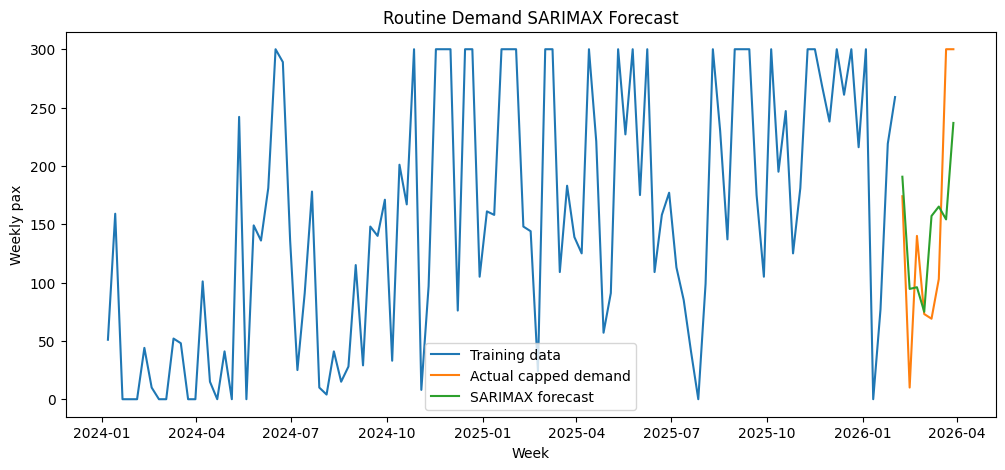

Routine SARIMAX MAE: 63.30938707903982
Routine SARIMAX RMSE: 76.03693719725753


In [422]:
# Fit routine SARIMAX model for capped routine demand
# Exogenous variables include trend, seasonality, holidays, and school vacations
model_rx = SARIMAX(
    train_ry,
    exog=train_rX,
    order=(0, 1, 1),
    seasonal_order=(1, 0, 0, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_rx = model_rx.fit(disp=False)

# Generate forecasts for the test period using the corresponding exogenous variables
forecast_rx = results_rx.forecast(
    steps=len(test_ry),
    exog=test_rX
)

forecast_rx = np.maximum(forecast_rx, 0)

# Visualise forecast performance
plt.figure(figsize=(12, 5))

plt.plot(train_ry.index, train_ry, label="Training data")
plt.plot(test_ry.index, test_ry, label="Actual capped demand")
plt.plot(forecast_rx.index, forecast_rx, label="SARIMAX forecast")

plt.title("Routine Demand SARIMAX Forecast")
plt.ylabel("Weekly pax")
plt.xlabel("Week")
plt.legend()

plt.show()

# Evaluate forecast accuracy
mae_rx = mean_absolute_error(test_ry, forecast_rx)
rmse_rx = np.sqrt(mean_squared_error(test_ry, forecast_rx))

print("Routine SARIMAX MAE:", mae_rx)
print("Routine SARIMAX RMSE:", rmse_rx)

## Routine demand model comparison

Forecasting performance for the routine-demand models was compared using MAE and RMSE metrics.

In [423]:
routine_comparison = pd.DataFrame({
    "Model": ["Routine naive baseline", "Routine SARIMA", "Routine SARIMAX"],
    "MAE": [baseline_r_mae, mae_r, mae_rx],
    "RMSE": [baseline_r_rmse, rmse_r, rmse_rx]
})

routine_comparison = routine_comparison.sort_values("RMSE")

routine_comparison

,Model,MAE,RMSE
2,Routine SARIMAX,63.309387,76.036937
1,Routine SARIMA,105.577967,116.503797
0,Routine naive baseline,133.375000,150.740257


## Comparing original and routine-demand forecasting

Finally, forecasting performance for the original weekly demand series and the capped routine-demand series was compared to evaluate whether reducing the influence of exceptional demand improved model performance overall.

In [424]:
final_comparison = pd.DataFrame({
    "Dataset": [
        "Original weekly demand",
        "Original weekly demand",
        "Original weekly demand",
        "Capped routine demand",
        "Capped routine demand",
        "Capped routine demand"
    ],
    "Model": [
        "Naive baseline",
        "SARIMA",
        "SARIMAX",
        "Naive baseline",
        "SARIMA",
        "SARIMAX"
    ],
    "MAE": [
        baseline_mae,
        mae_w,
        mae_x,
        baseline_r_mae,
        mae_r,
        mae_rx
    ],
    "RMSE": [
        baseline_rmse,
        rmse_w,
        rmse_x,
        baseline_r_rmse,
        rmse_r,
        rmse_rx
    ]
})

final_comparison = final_comparison.sort_values(
    ["Dataset", "RMSE"]
)

final_comparison

,Dataset,Model,MAE,RMSE
5,Capped routine demand,SARIMAX,63.309387,76.036937
4,Capped routine demand,SARIMA,105.577967,116.503797
3,Capped routine demand,Naive baseline,133.375000,150.740257
2,Original weekly demand,SARIMAX,114.942626,147.157934
1,Original weekly demand,SARIMA,158.190113,174.484920
0,Original weekly demand,Naive baseline,170.375000,180.979626


The routine-demand SARIMAX model achieved the lowest forecasting error among all evaluated models and therefore represented the best-performing forecasting approach within this study.

In contrast, forecasting performance on the original weekly demand series remained limited due to the influence of irregular exceptional-demand periods. This supports the distinction between routine operational demand and rare event-driven demand within hospitality forecasting contexts.